In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
'''
pandas 🧮: Used for loading, cleaning, transforming, and analyzing structured data with DataFrames and Series.

seaborn 🎨: High-level statistical data visualization library built on matplotlib for attractive and informative plots.

matplotlib 📊: Core plotting library in Python for creating customizable static, animated, and interactive visualizations.

ipywidgets 🎛️: Provides interactive UI controls (sliders, dropdowns, buttons) for Jupyter notebooks to explore data dynamically.

scikit-learn (sklearn) 🤖: Machine learning library offering tools for preprocessing, model building, evaluation, and model selection.
'''

'\npandas 🧮: Used for loading, cleaning, transforming, and analyzing structured data with DataFrames and Series.\n\nseaborn 🎨: High-level statistical data visualization library built on matplotlib for attractive and informative plots.\n\nmatplotlib 📊: Core plotting library in Python for creating customizable static, animated, and interactive visualizations.\n\nipywidgets 🎛️: Provides interactive UI controls (sliders, dropdowns, buttons) for Jupyter notebooks to explore data dynamically.\n\nscikit-learn (sklearn) 🤖: Machine learning library offering tools for preprocessing, model building, evaluation, and model selection.\n'

In [2]:
#DataFrame 🧾: A two-dimensional, labeled data structure in pandas used to store and manipulate tabular data.
#read_csv() 📂: A pandas function that reads data from a CSV file and loads it into a DataFrame.
df = pd.read_csv("/content/Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.info() #for analyzing the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
df["availability"].value_counts() #Which value appears how many times in that column

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


In [6]:
df["area_type"].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


<Axes: >

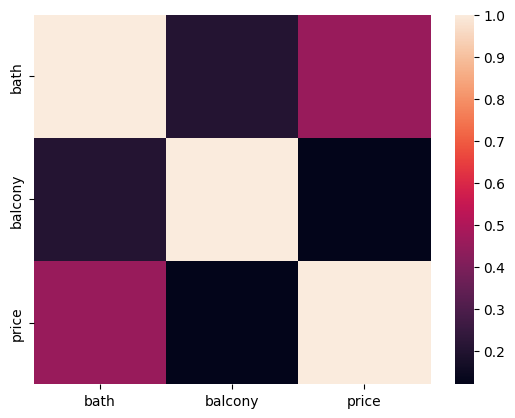

In [7]:
'''
Correlation 🔗 measures the strength and direction of the relationship between two variables in a dataset.
It indicates whether variables increase together (positive), move oppositely (negative), or have no linear relationship (near zero).
If two cloumns are related highly i.e. they are similar are highly correlated we can delete one of them to lessen the number of columns.

select_dtypes() 🧩: Selects DataFrame columns based on their data types (e.g., numeric, categorical) for targeted analysis.

.corr() 📐: Computes pairwise correlation coefficients between numerical columns in a DataFrame.

heatmap() 🔥: A seaborn function that visualizes values (such as correlations) as a color-coded matrix for easy comparison.
'''
corr = df.select_dtypes("number").corr()
sns.heatmap(corr) #sns is a library heps us to create heatmaps

In [8]:
df.isnull().sum() #for calcuating the number of null values in every coulmn

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [9]:
df1 = df.drop(columns = ['area_type','society','balcony','availability']) #for deleting unecessary columns
#df1 is a new dataframe as we don't want to delete columns from the original dataframe

In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [11]:
# .dropna(inplace=True) 🧹 removes rows (or columns) containing missing values from a DataFrame and applies the change directly without creating a new object.
df1.dropna(inplace = True) #inplace is FALSE by default as a security measure.
#True is used to tell pandas to modify the original DataFrame directly rather than returning a new one.
#Without inplace=True, the result of .dropna() must be reassigned to keep the changes.

In [12]:
df1.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [13]:
df1['size'].unique() #to get all the unique values of the size column

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [14]:
df1['bedrooms'] = df1['size'].apply(lambda x: int(x.split(" ")[0]))

'''
This line **creates a new `bedrooms` column** by extracting the number of bedrooms from the `size` column.
For each value in `size`, the lambda function splits the string by space, takes the first part (e.g., `"3"` from `"3 BHK"`),
converts it to an integer, and assigns it to `bedrooms`.
'''

'\nThis line **creates a new `bedrooms` column** by extracting the number of bedrooms from the `size` column.\nFor each value in `size`, the lambda function splits the string by space, takes the first part (e.g., `"3"` from `"3 BHK"`),\nconverts it to an integer, and assigns it to `bedrooms`.\n'

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bedrooms    13246 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 724.4+ KB


In [16]:
df1.head()

,location,size,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [17]:
df1 = df1.drop(columns = 'size')

In [18]:
df1['bedrooms'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [19]:
df1[df1.bedrooms>20] # checking those which have more than 20 bedrooms as it may be an error.

,location,total_sqft,bath,price,bedrooms
1718,2Electronic City Phase II,8000,27.0,230.0,27
4684,Munnekollal,2400,40.0,660.0,43


In [20]:
df1['total_sqft'].unique() # Displays all unique values in total_sqft to identify non-numeric entries like ranges and units
# the dtype is not integers because the values inside this column are of mixed format. SOme are integers, some are in range, some have sq. ft written with them.

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [21]:
# This function checks whether a value can be converted to a float, returning `True` if possible and `False` otherwise.

def is_float(x):
  try:
    float(x)
  except:
    return False
  return True

In [22]:
df1[~df1['total_sqft'].apply(is_float)].head(10)
#This line displays the first 10 rows where total_sqft cannot be converted to a float, helping identify non-numeric or irregular values in the column.

# The tilde ~ 🔄 is a logical NOT operator in pandas, used to invert the boolean result.
# Here, it selects rows where is_float returns False instead of True.

,location,total_sqft,bath,price,bedrooms
30,Yelahanka,2100 - 2850,4.0,186.000,4
122,Hebbal,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,43.490,2
188,KR Puram,1015 - 1540,2.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,63.770,2
648,Arekere,4125Perch,9.0,265.000,9
661,Yelahanka,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,445.000,4


In [23]:
'''
This function converts `total_sqft` values into a numeric form by handling floats directly,
averaging range values (e.g., `"2100-2850"`), converting valid numeric strings,
and returning `None` for invalid formats.
'''
def convert_sqft_to_num(x):
  if isinstance(x, float):  # Check if x is already a float
        return x
  tokens = x.split('-') #A token 🧩 is a small unit obtained by splitting a string; here, tokens are the parts of x created by splitting it on '-' (e.g., "2100-2850" → ["2100", "2850"]).
  if len(tokens) == 2:
      return (float(tokens[0])+float(tokens[1]))/2
  try:
      return float(x)
  except:
      return None

In [24]:
df4 = df1.copy() # Creating a separeate copy of df1 to avoid modifying the original dataframe.
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)  # converting all total_sqft values into numeric form using the custom fucntion.
df4.dropna(inplace=True) # Removing rows where the conversion failed and resulted in missing values

df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13200 non-null  object 
 1   total_sqft  13200 non-null  float64
 2   bath        13200 non-null  float64
 3   price       13200 non-null  float64
 4   bedrooms    13200 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 618.8+ KB


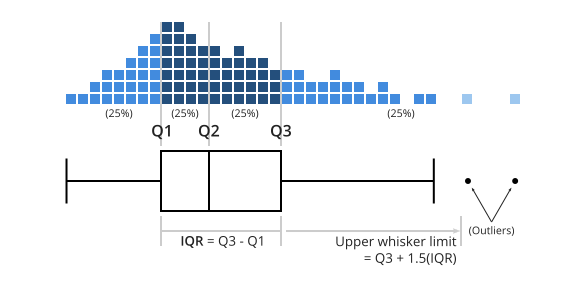

{'whiskers': [<matplotlib.lines.Line2D at 0x7dfa0082b3b0>,
 'caps': [<matplotlib.lines.Line2D at 0x7dfa008816d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7dfa00802690>],
 'medians': [<matplotlib.lines.Line2D at 0x7dfa00881f10>],
 'fliers': [<matplotlib.lines.Line2D at 0x7dfa008822d0>],
 'means': []}

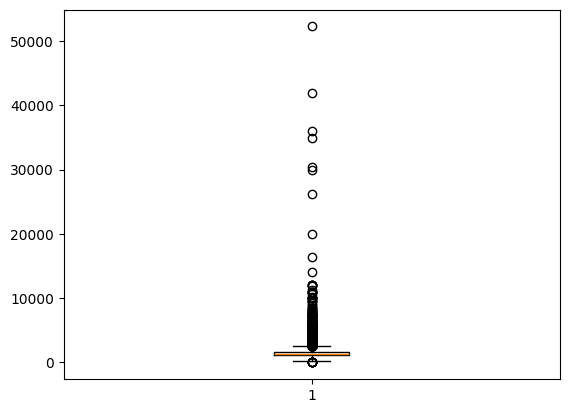

In [25]:
'''
Outliers ⚠️
Outliers are data points that lie far away from the majority of observations and do not follow the general pattern of the data.

Effects of outliers 📉
They can skew distributions, distort statistical measures like mean and variance, and negatively impact machine learning model performance.

How to remove outliers 🧹
Common methods include IQR (interquartile range), Z-score, percentile capping, or domain-based filtering.

Why it is important to remove them 🎯
Removing outliers improves data quality, model stability, and ensures more reliable and interpretable results.
'''
'''
A box plot (aka box and whisker plot) uses boxes and lines to depict the distributions of one or more groups of numeric data.
Box limits indicate the range of the central 50% of the data, with a central line marking the median value.
Lines extend from each box to capture the range of the remaining data, with dots placed past the line edges to indicate outliers.

The first quartile (Q1) is greater than 25% of the data and less than the other 75%.
The second quartile (Q2) sits in the middle, dividing the data in half. Q2 is also known as the median.
The third quartile (Q3) is larger than 75% of the data, and smaller than the remaining 25%.
In a box and whiskers plot, the ends of the box and its center line mark the locations of these three quartiles.
'''
plt.boxplot(df4['total_sqft'])  # the  box in the graph represents the 25-75 perc of the points. THe orange line is 50 perc line

In [26]:
df4['total_sqft'].describe()

,total_sqft
count,13200.000000
mean,1555.302783
std,1237.323445
min,1.000000
25%,1100.000000
50%,1275.000000
75%,1672.000000
max,52272.000000


In [27]:
# In general and in most cases most of the outlier dta lies in the top and the last 10 perc of the whole data so we remove that.
low, high = df4['total_sqft'].quantile([0.1, 0.9]) # 0.1 means 10% and 0.9 means 90% which is the new range for us now, rest of the dtat points are outliers.
mask_area = df4['total_sqft'].between(low, high)
df4 = df4[mask_area]

{'whiskers': [<matplotlib.lines.Line2D at 0x7dfa008ab530>,
 'caps': [<matplotlib.lines.Line2D at 0x7df9fe6fc500>,
 'boxes': [<matplotlib.lines.Line2D at 0x7df9fe6fe1b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7df9fe6fea80>],
 'fliers': [<matplotlib.lines.Line2D at 0x7df9fe6fed80>],
 'means': []}

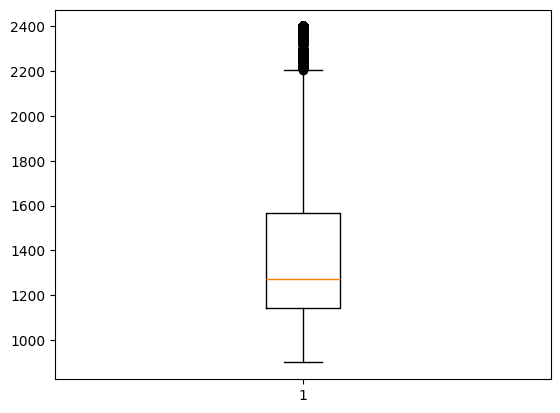

In [28]:
plt.boxplot(df4['total_sqft'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7df9fe7a4e00>,
 'caps': [<matplotlib.lines.Line2D at 0x7df9fe7a5430>,
 'boxes': [<matplotlib.lines.Line2D at 0x7df9fe7093a0>],
 'medians': [<matplotlib.lines.Line2D at 0x7df9fe7a5a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7df9fe7a5d60>],
 'means': []}

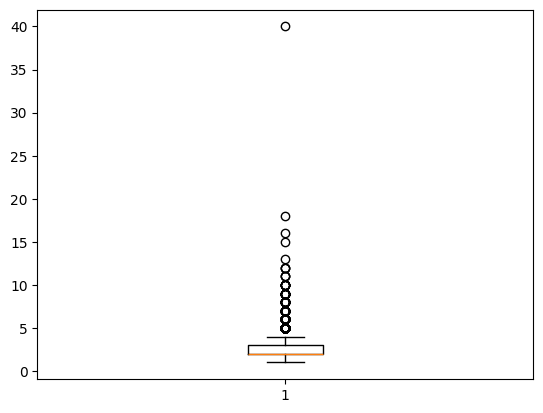

In [29]:
plt.boxplot(df4['bath'])

In [30]:
df4['bath'].describe()

,bath
count,10594.000000
mean,2.556069
std,1.088512
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,40.000000


In [31]:
df4['bath'].value_counts()

,count
bath,
2.0,6468
3.0,2933
4.0,632
5.0,190
1.0,135
6.0,117
7.0,46
8.0,31
9.0,22


In [32]:
df4 = df4[df4['bath']<12] # Here we are updating the dataset so that only those entries which have less than 12 bathrooms are kept, rest may be ouliers so we remove them.

In [33]:
df4['bath'].value_counts()

,count
bath,
2.0,6468
3.0,2933
4.0,632
5.0,190
1.0,135
6.0,117
7.0,46
8.0,31
9.0,22


{'whiskers': [<matplotlib.lines.Line2D at 0x7df9fe60a0f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7df9fe60a690>,
 'boxes': [<matplotlib.lines.Line2D at 0x7dfa008593a0>],
 'medians': [<matplotlib.lines.Line2D at 0x7df9fe60aba0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7df9fe60ae40>],
 'means': []}

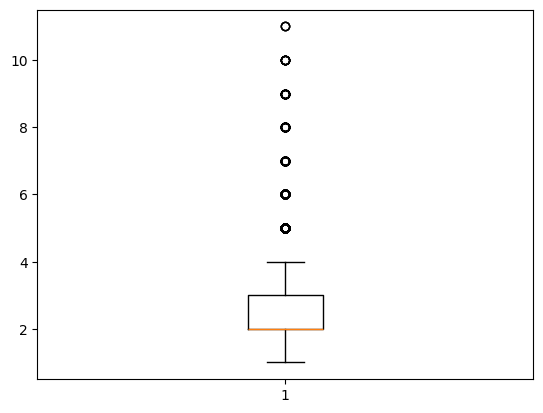

In [34]:
plt.boxplot(df4['bath'])

In [35]:
df4.head()

,location,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,1056.0,2.0,39.07,2
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
5,Whitefield,1170.0,2.0,38.00,2


In [36]:
df4['price_per_sqft'] = df4['price']*100000/df4['total_sqft'] #This line creates a new column `price_per_sqft` by converting price to absolute value and dividing it by `total_sqft`, giving the cost per square foot for each property.

In [37]:
df4.head()

,location,total_sqft,bath,price,bedrooms,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,1170.0,2.0,38.00,2,3247.863248


In [38]:
df4['price_per_sqft'].describe()

,price_per_sqft
count,10586.000000
mean,6244.315309
std,3698.326765
min,500.000000
25%,4206.709513
50%,5252.421226
75%,6761.335502
max,53150.000000


In [39]:
low, high = df4['price_per_sqft'].quantile([0.1, 0.9])
mask_area = df4['price_per_sqft'].between(low, high)
df4 = df4[mask_area]

In [40]:
df4['price_per_sqft'].describe()

,price_per_sqft
count,8468.000000
mean,5525.927314
std,1399.739284
min,3500.408831
25%,4422.310757
50%,5252.421226
75%,6364.809866
max,9904.371585


{'whiskers': [<matplotlib.lines.Line2D at 0x7df9fe64bad0>,
 'caps': [<matplotlib.lines.Line2D at 0x7df9fe67c140>,
 'boxes': [<matplotlib.lines.Line2D at 0x7df9fe648230>],
 'medians': [<matplotlib.lines.Line2D at 0x7df9fe67c710>],
 'fliers': [<matplotlib.lines.Line2D at 0x7df9fe67c9e0>],
 'means': []}

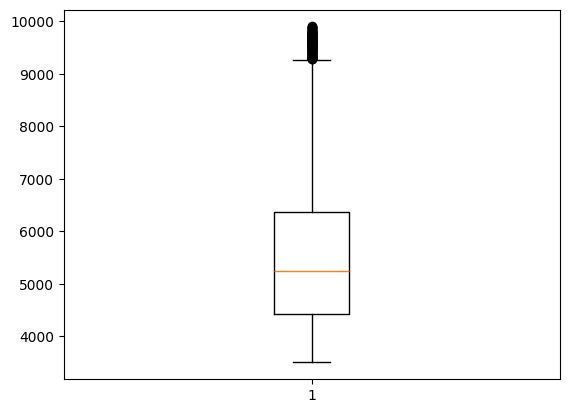

In [41]:
plt.boxplot(df4['price_per_sqft'])

In [42]:
df4.location = df4.location.apply(lambda x: x.strip()) # 🧹: Removes leading and trailing spaces from location names to ensure consistency
location_stats = df4['location'].value_counts(ascending = False) # 📊: Counts occurrences of each location and sorts them from most to least frequent.
location_stats # 📋: Stores and displays the frequency of properties per location.

,count
location,
Whitefield,355
Sarjapur Road,293
Kanakpura Road,205
Thanisandra,189
Electronic City,167
...,...
Madiwala,1
Jogupalya,1
Subhash Nagar,1


In [43]:
location_stats_less_than_10 = location_stats[location_stats<=10] # Filtering locations that appear 10 times or less in the dataset
len(location_stats_less_than_10) # to get a count of how many such low frequency locations exist.

765

In [44]:
df4.location.nunique() # nunique means number of unique values

934

In [45]:
df4.location = df4.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x) # This line groups all rare locations (appearing ≤10 times) under a single category 'other' to reduce dimensionality 🧩.
len(df4.location.unique())# shows the updated number of unique location categories after this consolidation.

170

In [46]:
df4.head(10)

,location,total_sqft,bath,price,bedrooms,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
8,Marathahalli,1310.0,3.0,63.25,3,4828.244275
10,Whitefield,1800.0,2.0,70.00,3,3888.888889
12,7th Phase JP Nagar,1000.0,2.0,38.00,2,3800.000000
13,Gottigere,1100.0,2.0,40.00,2,3636.363636
14,Sarjapur,2250.0,3.0,148.00,3,6577.777778
15,Mysore Road,1175.0,2.0,73.50,2,6255.319149


In [47]:
df4 = df4.drop(columns = 'price_per_sqft')

In [48]:
#Now we have to encode the text columns. We use category_encoders library for this.
!pip install category_encoders

# Category encoders 🔁 are used to convert categorical variables into numerical representations using techniques like target encoding, one-hot encoding, or ordinal encoding.
# Examples of categorical columns 🏷️ include variables that represent labels or groups rather than numeric values, such as:
# location, city, gender, property_type, furnishing_status, and ownership_type
# Machine learning models operate on numerical inputs, so categorical/text columns must be encoded to be usable ⚙️.
# Ignoring them discards important information (e.g., location), which reduces model accuracy and predictive power

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.7 MB/s eta 0:00:00


In [49]:
from category_encoders import OneHotEncoder
# OneHotEncoder 🧩 converts a categorical column into multiple binary (0/1) columns, one for each category.

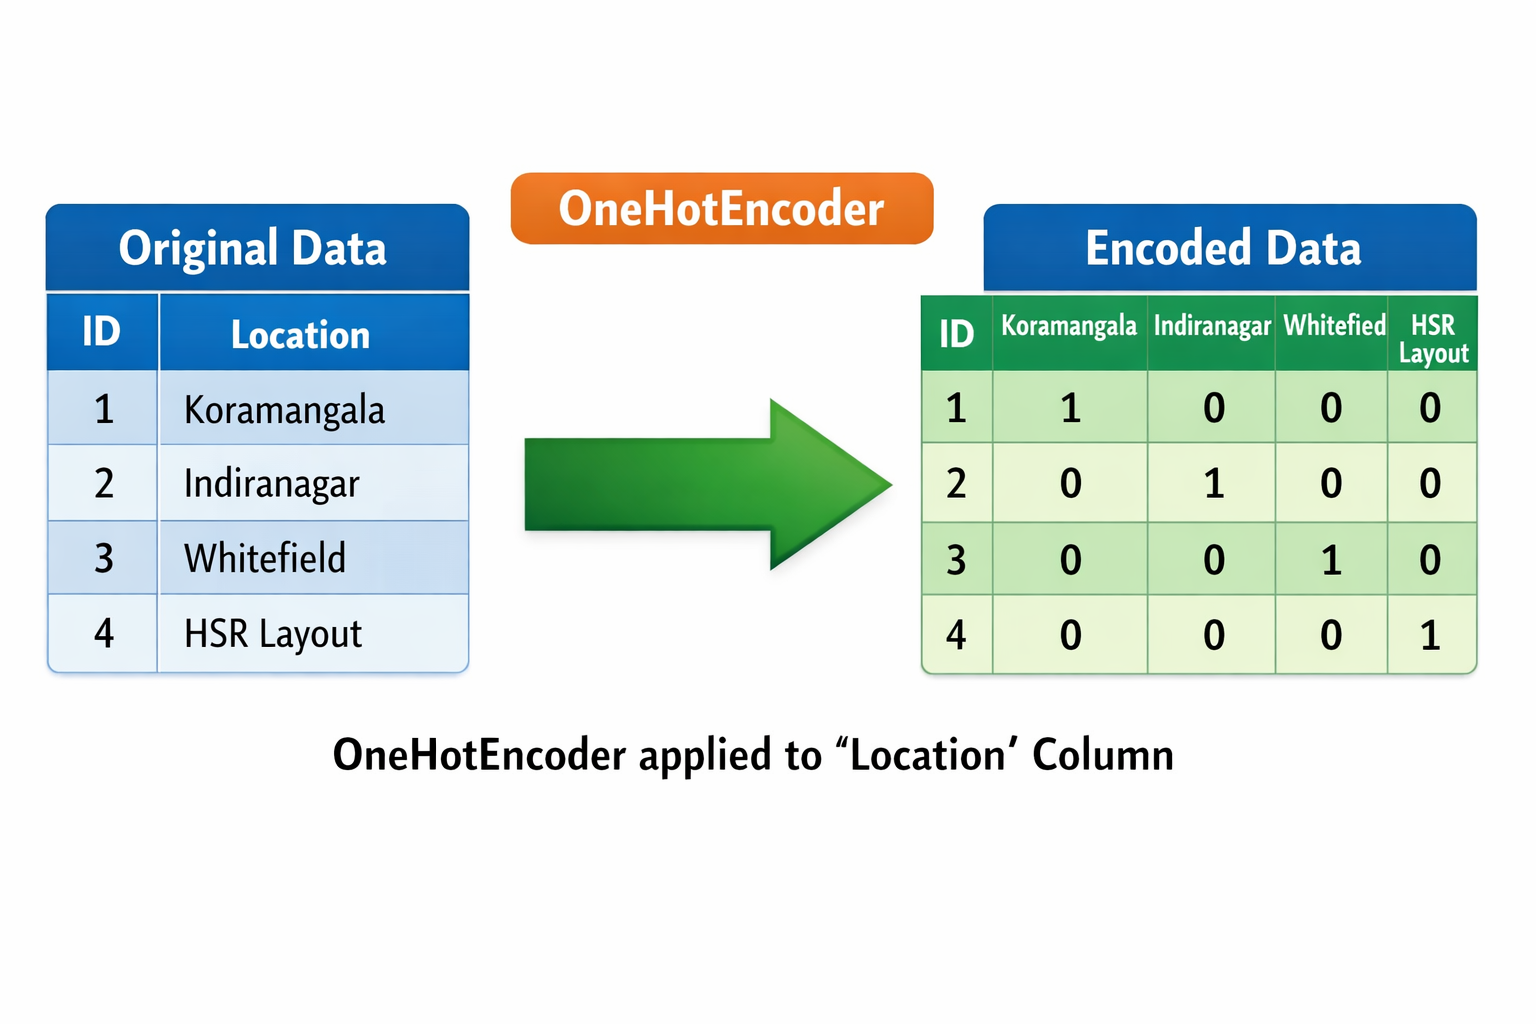

In [50]:
x = df4.drop(['price'],axis = 'columns') # X is input and Y is output. So, we remove Price form X as Price is the output and will be kept in Y.

In [51]:
y = df4.price

In [52]:
# We have to split the data into the training data and testing data using an inbuilt function.
# We split data into training and testing sets 🧪 to evaluate how well the model generalizes to unseen data.
# Training on all data can cause overfitting and gives an overly optimistic performance estimate, reducing reliability.

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 10)

# splits the dataset into 80% training and 20% testing data 🧪, with random_state=10 ensuring the split is reproducible.
# random state helps us in ensuring each time the same rows are selected for testing ensuring consistency in results.
# The value 10 in random_state=10 🧩 is simply a seed number for the random number generator.
# It has no special meaning by itself—any integer would work—but using the same value guarantees the same sequence of random choices and thus the same data split.

In [53]:
# A pipeline is a structured sequence that chains preprocessing steps (scaling, encoding, feature selection) and a model into a single workflow executed in a fixed order.
# Importance: It ensures the same transformations are applied during training and prediction, reducing data leakage and human error.
'''
Pipeline advantages over alternatives 🎯

vs Manual steps: Prevents forgetting or misordering transformations; improves reproducibility.

vs Custom scripts: Easier integration with cross-validation and hyperparameter tuning.

vs Ad-hoc workflows: Enforces consistency, cleaner code, and safer deployment behavior.
'''

# Linear Regression 📈 is a supervised learning algorithm that models the relationship between input features and a continuous target using a linear equation.

model = make_pipeline(OneHotEncoder(), LinearRegression())
model.fit(x_train, y_train)

Pipeline(steps=[('onehotencoder', OneHotEncoder(cols=['location'])),
                ('linearregression', LinearRegression())])

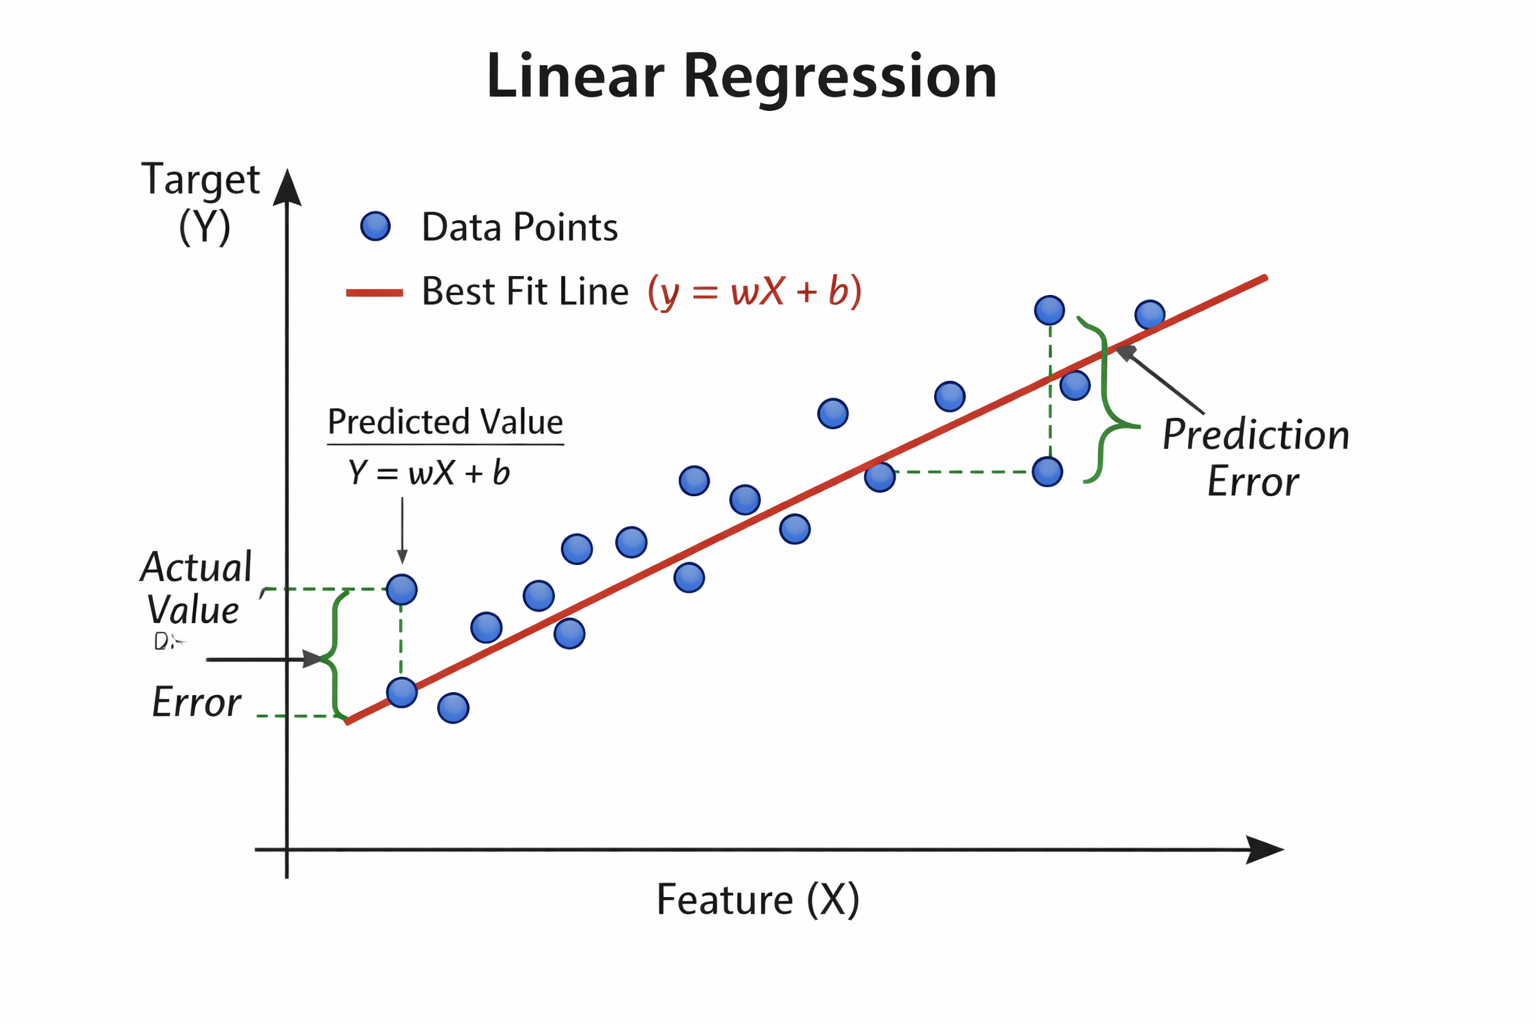

In [54]:
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred) # computes the average absolute difference between actual and predicted values, measuring prediction accuracy.
mae

# MAE (Mean Absolute Error) 📏 is reliable because it measures the average magnitude of errors in the same units as the target variable, making it easy to interpret.
# It treats all errors equally (no squaring), is less sensitive to extreme outliers, and gives a realistic sense of typical prediction error.

13.591634884069956

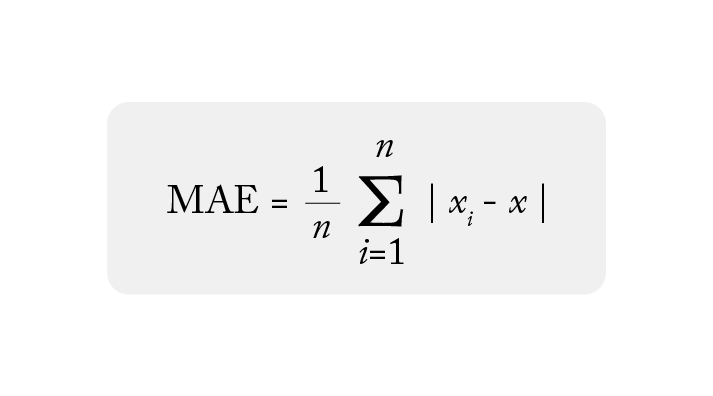

n = total number of data points ||
xi = actual values ||
x = predicted value

In [55]:
from sklearn.metrics import mean_absolute_percentage_error as error
# calculating the average percentage difference between actual and predicted values.
mae = error(y_test, y_pred)
mae

# This is done so that the mean prediction error becomes scale independent and can be easily comapred across datasets.

0.17664696219476128

In [56]:

def predict_price(input_data: dict): # We accept the input features as a dictionary, making it suitable for real-world use(like in Apps and APIs)
    '''
    Predict house price based on input features

    Parameters:
    input_data (dict): Feature-value pairs

    Returns:
    float: Predicted house price
    '''
    input_df = pd.DataFrame([input_data]) # converting the dictionary into a single line dataframe matching the model's expected input format.
    return model.predict(input_df)[0] # running the same preprocessing and regression steps.
    # [0] 📌 is used to extract the first (and only) value from the prediction output.
    # model.predict() returns a NumPy array, and since we predict for a single row, [0] retrieves the single predicted price.


# Example prediction
example_house = {
    'location': 'Whitefield',
    'total_sqft': 1200,
    'bath': 2,
    'bedrooms':2
}

print("Predicted Price:", predict_price(example_house))


Predicted Price: 62.99548916417295
